# Модели стационарных временных рядов

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm
import pylab 
import scipy.stats as stats
import statsmodels as sm

В этой лекции через $y_t$ будет обозначать наблюдаемый случайный процесс, а $\epsilon_t$ ненаблюдаемый процесс белого шума.

**Общим линейным процессом типа скользящего среднего называется процесс вида**
$$y_t=\epsilon_t+\psi_1\epsilon_{t-1}+\psi_2\epsilon_{t-2}+....+\psi_n\epsilon_{t-n}+....$$
Введем линейный оператор сдвига назад
$B: By_t=y_{t-1}$

По индукции 
$B^k: B^ky_t=y_{t-k}$

Используя оператор сдвига, определение линейного  процесса типа скользящего среднего будем записывать в операторном виде
$y_t=(1+\psi_1B+\psi_2B^2+.....)\epsilon_t= \psi(B)\epsilon_t$


Будем предполагать, что

$\sum_{i=1}^{\infty}\psi_i < \infty$

Важный нетривиальный пример такого процесса это процесс, где все
$\psi_i=\phi^i$, при $-1<\phi<1$ 

В этом случае

$$y_t= (1+\phi B+\phi^2B^2+...)\epsilon_t=\epsilon_t+\phi\epsilon_{t-1}+\phi^2\epsilon_{t-2}+...$$

Так как $\epsilon_t$ - процесс белого шума  $E[\epsilon_t]=0$, поэтому

$E[y_t]=E[\epsilon_t+\phi\epsilon_{t-1}+\phi^2\epsilon_{t-2}+...]= 0$

Пусть $D[\epsilon_t]=\sigma_{\epsilon}^2$ тогда

$D[y_t]=D[\epsilon_t+\phi\epsilon_{t-1}+\phi^2\epsilon_{t-2}+...]= \sigma_{\epsilon}^2+\phi^2\sigma_{\epsilon}^2+\phi^4\sigma_{\epsilon}^2+... = \sigma_{\epsilon}^2(1+\phi^2+\phi^4+...)= \frac{\sigma_{\epsilon}^2}{1-\phi^2}$

Вычислим автоковариационную и автокорреляционную функции процесса

$c_1=cov(y_t,y_{t-1})= cov((\epsilon_t+\phi\epsilon_{t-1}+\phi^2\epsilon_{t-2}+...),( \epsilon_{t-1}+\phi\epsilon_{t-2}+\phi^2\epsilon_{t-3}+...))= \phi\sigma_{\epsilon}^2(1+\phi^2+\phi^4+...)=\frac{\phi\sigma_{\epsilon}^2}{1-\phi^2}$

$corr(y_t,y_{t-1})= \frac{\phi\sigma_{\epsilon}^2}{1-\phi^2}/(\frac{\sigma_{\epsilon}^2}{1-\phi^2})= \phi$

Аналогично вычислим 

$c_k=cov(y_t,y_{t-k})=\frac{\phi^k\sigma_{\epsilon}^2}{1-\phi^2}$

$\gamma_k=corr(y_t,y_{t-k})=\phi^k$  

Для произвольного линейного процесса скользящего среднего  $y_t=(1+\psi_1B+\psi_2B^2+.....)\epsilon_t= \psi(B)\epsilon_t$
Нетрудно вычислить, что

$E[y_t=0]$,

$c_k=cov(y_t,y_{t-k})=\sigma_{\epsilon}^2\sum_{i=0}^{\infty}\psi_i\psi_{i+k}$

Важно отметить, что ковариационная функция не зависит от $t$
, зависит только от задержки $k$ cледовательно это стационарный процесс
с нулевым среднем. Для получения процесса с произвольным среднем $\mu$ просто добавим $\mu$ к правой части соотношения 
$y_t=(1+\psi_1B+\psi_2B^2+.....)\epsilon_t+\mu= \psi(B)\epsilon_t+\mu$

В случае конечного числа $\psi_k$ отличных от нуля модель записывают
в виде

$y_t=\mu+\epsilon_t-\theta_1\epsilon_1- ...-\theta_q\epsilon_q$ 

называют **моделью скользящего среднего порядка $q$ и обозначают $MA(q)$**

## Модель $MA(1)$

Подробно рассмотрим модель скользящего среднего первого порядка с нулевым среднем $y_t=\epsilon_t-\theta\epsilon_{t-1}$

Cогласно проведенным выше вычислениям сразу запишем, что
автоковариационная функция процесса $y_t$

$c_0=D[y_t]= \sigma_{\epsilon}^2(1+\theta^2)$

$c_1=cov(y_t,y_{t-1})=-\sigma_{\epsilon}^2\theta$

$c_k = 0$ при $|k|>1$

автокорреляционная функция процесса $y_t$

$\rho_0=1$

$\rho_1= -\theta/(1+\theta^2)$

$\rho_k= 0$ при $|k|>1$


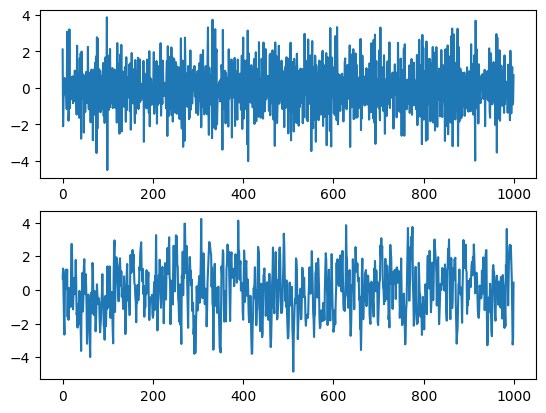

In [2]:
# Plot 1: MA parameter: -0.9
plt.subplot(2, 1, 1)
ar1 = np.array([1])
ma1 = np.array([1,  -0.9])
MA_object1 = ArmaProcess(ar1, ma1)
simulated_data_1 = MA_object1.generate_sample(nsample=1000)
plt.plot(simulated_data_1);

# Plot 2: MA parameter: +0.9
plt.subplot(2, 1, 2)
ar2 = np.array([1])
ma2 = np.array([1, 0.9, 0.9**2])
MA_object2 = ArmaProcess(ar2, ma2)
simulated_data_2 = MA_object2.generate_sample(nsample=1000)
plt.plot(simulated_data_2);

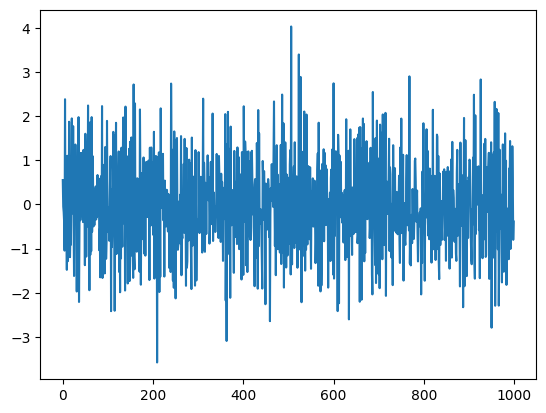

In [4]:
ar3 = np.array([1])
ma3 = np.array([1, -0.3])
MA_object3 = ArmaProcess(ar3, ma3)
simulated_data_3 = MA_object3.generate_sample(nsample=1000)
plt.plot(simulated_data_3)

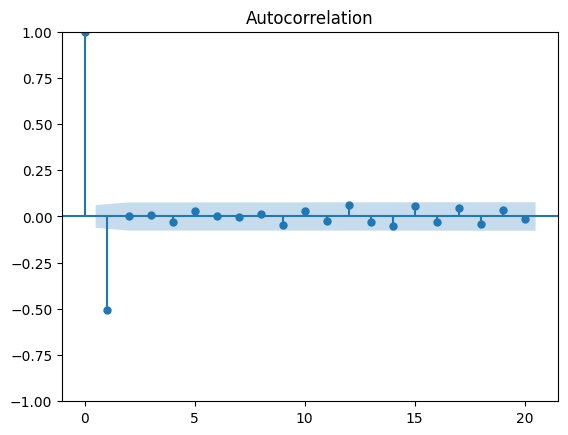

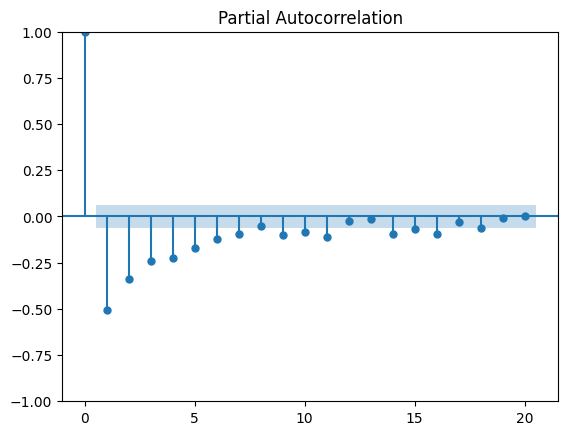

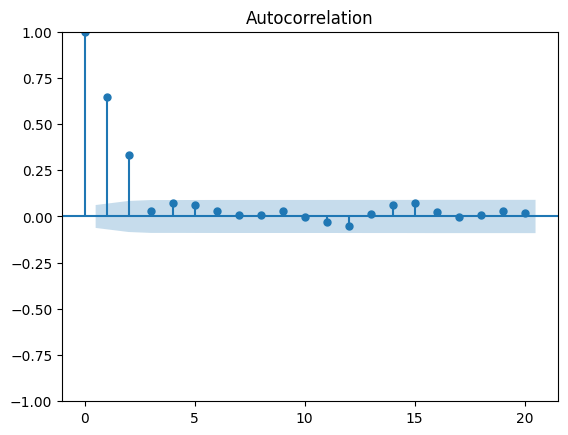

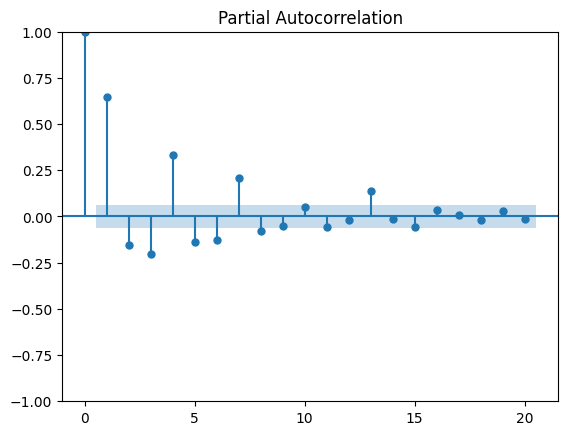

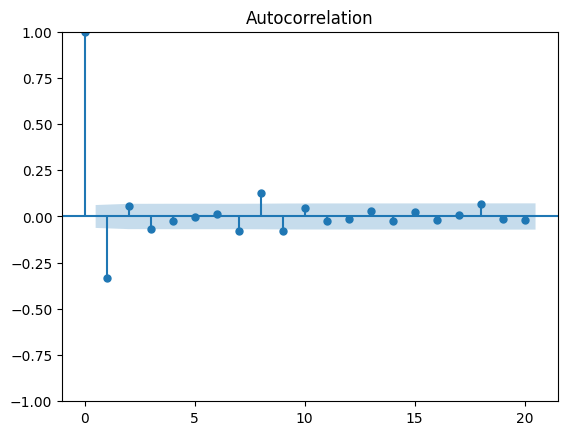

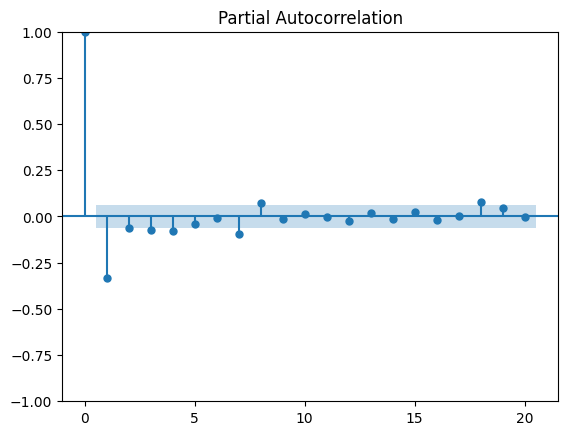

In [5]:
# Plot 1: MA parameter = -0.9
plot_acf(simulated_data_1, lags=20)
plot_pacf(simulated_data_1, lags=20)

# Plot 2: MA parameter = +0.9
plot_acf(simulated_data_2, lags=20)
plot_pacf(simulated_data_2, lags=20)

# Plot 3: MA parameter = -0.3
plot_acf(simulated_data_3, lags=20)
plot_pacf(simulated_data_3, lags=20)
plt.show()

## Процесс $MA(q)$

Теперь рассмотрим процесс скользящего среднего произвольного порядка $MA(q)$

$y_t=\epsilon_t-\theta_1\epsilon_{t-1}-...-\theta_q\epsilon_{t-q}$

Для процесса $y_t$ дисперсия

$c_0=D[y_t]=\sigma_{\epsilon}^2(1+\theta_1^2+....+\theta_q^2)$

автокорреляционная функция

$\rho_k= \frac{-\theta_{k}+\theta_{k-1}\theta_{1}-\theta_{k-2}\theta_{2}+\theta_{k-q}\theta_{q}}{(1+\theta_1^2+....+\theta_q^2)}$ при $k=1,...,q$

$\rho_k=0$ при $k>q$


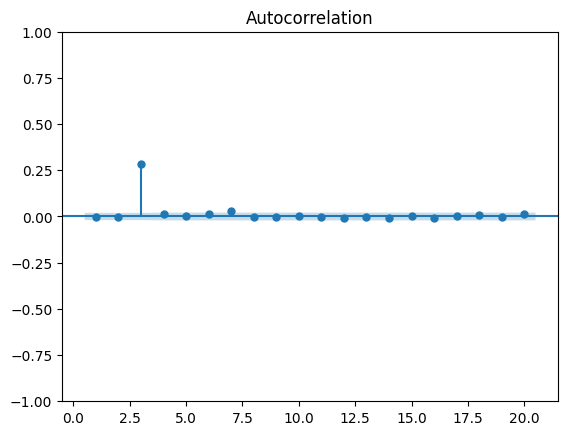

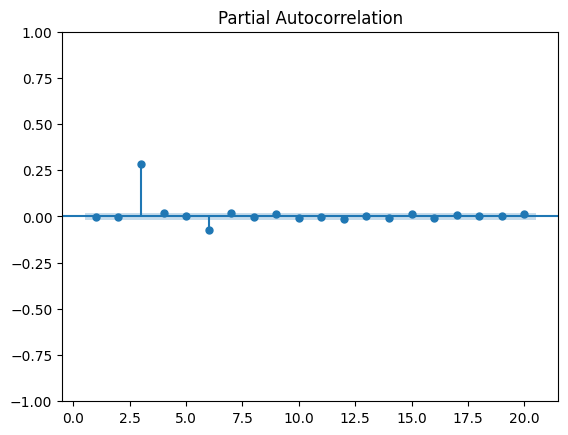

In [7]:
## Модель $MA(3)$
ar1 = np.array([1])
ma3 = np.array([3, 0, 0, 0.9])
MA_object1 = ArmaProcess(ar1, ma3)
simulated_data = MA_object1.generate_sample(nsample=10**4)
plot_acf(simulated_data, lags=20, zero=False)
plot_pacf(simulated_data, lags=20, zero=False)
plt.show()

## Процессы авторегрессии

Общим **линейным процессом типа авторегрессии называется** процесс вида
$$y_t=\epsilon_t+\pi_1y_{t-1}+\pi_2y_{t-2}+....+\pi_ny_{t-n}+....$$
или в операторном виде
$$\pi(B)y_t=\epsilon_t$$

Название происходит от регрессии самого на себя. Процесс вида


$y_t= \phi_1y_{t-1}+\phi_2y_{t-2}+...+\phi_py_{t-p}+\epsilon_t$

назвается процессом авторегрессии порядка $p$ обозначается $AR(p)$.
Запись с использованием оператора сдига назад $B$ и в операторной форме

$(1 - \phi_1B-\phi_2B^2-...- \phi_pB^p) y_t=\phi(B)y_t=\epsilon_t$

**Соотношение между $\pi(B)$ и $\psi(B)$**
Итак мы имеем два типа предствления
	$$ \pi(B)x_{t}=\epsilon_{t} $$
и
	$$x_{t}=\psi(B)\epsilon_{t}$$

    
Умножим первое из них слева на $\psi(B)$
$$\psi(B)\pi(B)x_{t}=\psi(B)\epsilon_{t}=x_{t}$$
Отсюда следует, что
$\psi(B)\pi(B)=1$
или
$\psi(B)=\pi^{-1}(B)$


### Процесс авторегрессии 1 порядка $AR(1)$

Пусть стационарный процесс c нулевым среднем представим в виде

$y_t=\phi y_{t-1}+\epsilon_t$

или, используя оператор сдвига 

$\phi(B)y_t = \epsilon_t$

где $\phi(B)=1-\phi B$

Вычислим дисперсию $c_0=D[y_t]$ 

$c_0=\phi^2c_0+\sigma_{\epsilon}^2$

Умножая выражение для процесса на $y_{t-k}$ и ,беря математическое ожидание от обеих частей получим выражение для ACF процесса

$E[y_ty_{t-k}]= \phi E[y_{t-1}y_{t-k}]+E[\epsilon_ty_{t-k}]$

$c_k= \phi c_{k-1}$

Откуда 

$c_k=\phi^k \frac{\sigma_{\epsilon}^2}{1-\phi^2}$


Автокорреляционная функция 

$\rho_k=\frac{c_k}{c_0}=\phi^k$

Предположим, чья $|\phi |< 1$ в этом случае $\rho_k \to 0$ при $k \to \infty$

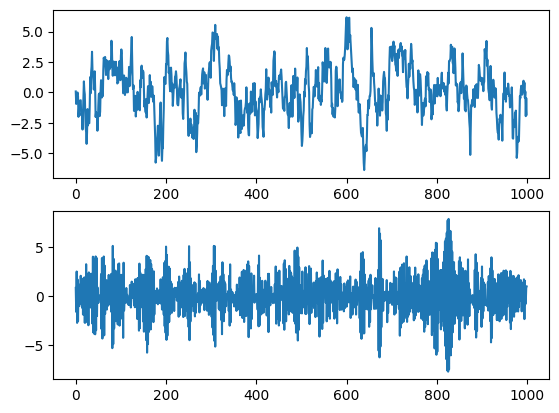

In [8]:
# Plot 1: AR parameter = -0.9
plt.subplot(2, 1, 1)
ar1 = np.array([1, -0.9])
ma1 = np.array([1])
AR_object1 = ArmaProcess(ar1, ma1)
simulated_data_1 = AR_object1.generate_sample(nsample=1000)
plt.plot(simulated_data_1);

# Plot 2: AR parameter = 0.9
plt.subplot(2, 1, 2)
ar2 = np.array([1, 0.9])
ma2 = np.array([1])
AR_object2 = ArmaProcess(ar2, ma2)
simulated_data_2 = AR_object2.generate_sample(nsample=1000)
plt.plot(simulated_data_2);

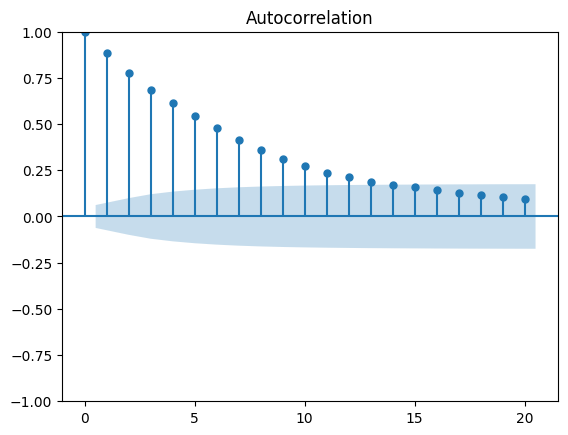

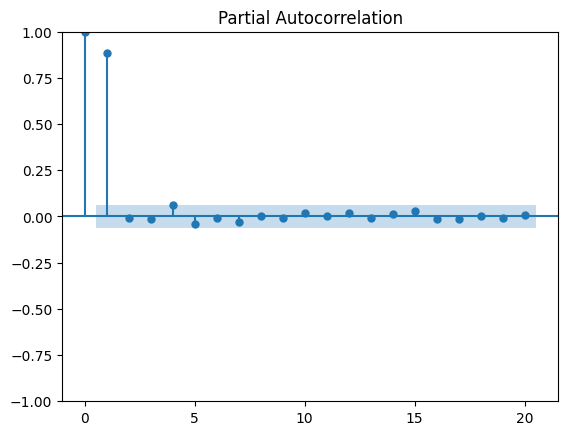

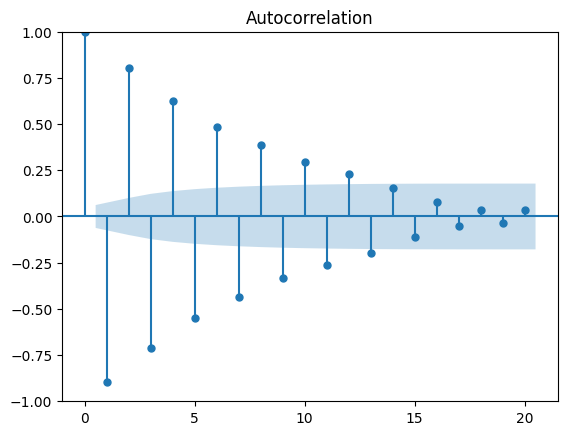

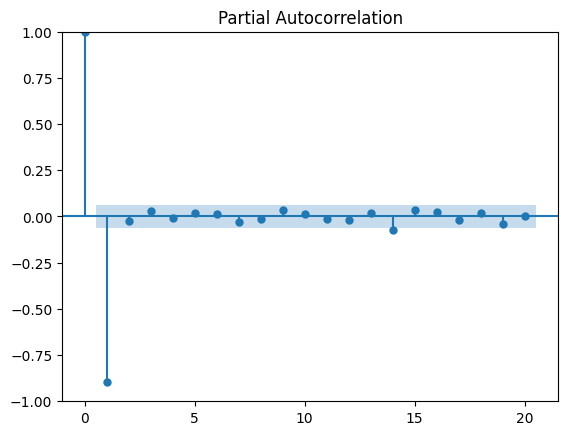

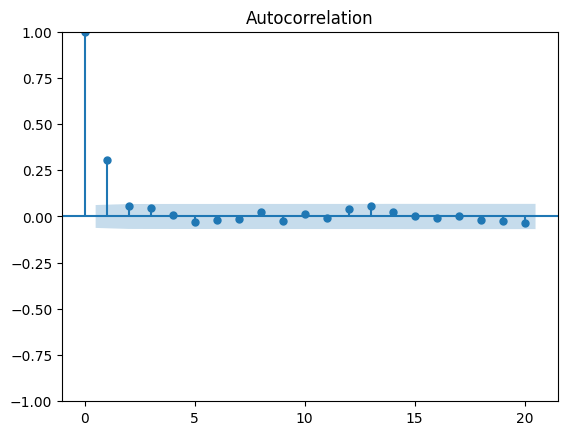

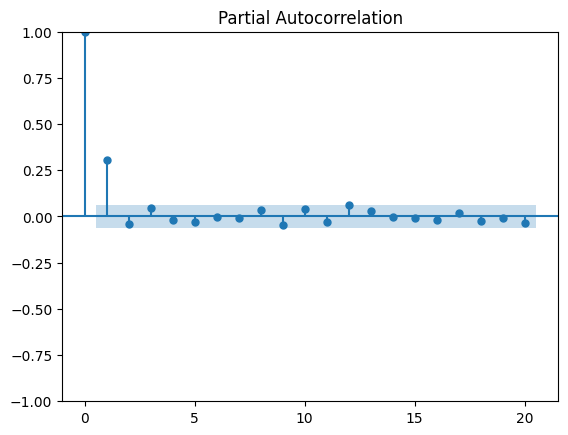

In [10]:
ar3 = np.array([1, -0.3])
ma3 = np.array([1])
AR_object3 = ArmaProcess(ar3, ma3)
simulated_data_3 = AR_object3.generate_sample(nsample=1000)

# Plot 1: AR parameter = +0.9
plot_acf(simulated_data_1, lags=20)
# Plot 1: AR parameter = +0.9
plot_pacf(simulated_data_1, lags=20)


# Plot 2: AR parameter = -0.9
plot_acf(simulated_data_2, lags=20)
# Plot 2: AR parameter = -0.9
plot_pacf(simulated_data_2, lags=20)


# Plot 3: AR parameter = +0.3
plot_acf(simulated_data_3, lags=20)
# Plot 3: AR parameter = +0.3
plot_pacf(simulated_data_3, lags=20)
plt.show()






## Процесс авторегрессии 2 порядка. $AR(2)$

Пусть процесс c нулевым среднем представим в виде

$y_t=\phi_1 y_{t-1}+\phi_2 y_{t-2}+ \epsilon_t$

или, используя оператор сдвига 


$\phi (B)x_t = \epsilon_t$

где $\phi(B)=1-\phi_1 B- \phi_2 B^2$

Можно покачать, что для стационарности $AR(2)$ процесса необходимо и достаточно, чтобы корни характеристического уравнения $\phi(B) = 0$  или $1-\phi_1 B- \phi_2 B^2=0$ по модулю были больше 1. Корни характеристического уравнения легко найти

$B_{1,2}=\frac{\phi_1+-\sqrt{\phi_1^2+4\phi_2}}{-2\phi_2}$

Абсолютные значения корней должны быть больше 1. Отсюда можно получить условия на $\phi_1,\phi_2$ а именно

$\phi_1+\phi_2<1$,$\phi_2-\phi_1<1$ и $|\phi_2|<1$ 

Вычислим автоковариационную и автокорреляционную функции процесса $AR(2)$
Умножая предствление процесса на $y_{t-k}$ и, беря математическое ожидание, получим

$c_k= \phi_1c_{k-1}+\phi_2c_{k-2}$  $:k=1,2,....$

автокорреляционная функция

$\rho_k= \phi_1\rho_{k-1}+\phi_2\rho_{k-2}$  $:k=1,2,....$

Последнее уравнение носит название уравнение Юла-Уокера. Его обычно решают численно, но существует и другой способ нахождения $\rho_k$
обозначим через $G_1,G_2$ корни характеристического уравнения $1-\phi_1 B- \phi_2 B^2=0$

$G_1= \frac{\phi_1+\sqrt{\phi_1^2+4\phi_2}}{2}$

$G_2= \frac{\phi_1-\sqrt{\phi_1^2+4\phi_2}}{2}$

Если $G_1\ne G_2$
то можно показать,что

$\rho_k=\frac{(1-G_2^2)G_1^{k+1}- (1-G_1^2)G_2^{k+1}}{(G_1-G_2)(1+G_1G_2)}$

Eсли корни комплексны, тогда

$\rho_k=R^k\frac{sin(\Theta k+\Phi)}{sin\Phi}$

где $R =\sqrt{-\phi_2}$,  $cos\Theta=\phi_1/(2\sqrt{-\phi_2})$ и $tan\Phi=(1-\phi_2)/(1+\phi_2)$

Поведение процесса, выборочной и модельной (True ACF) автокорреляционной  функции при различных параметрах $\phi_1,\phi_2$ можно изучить в прилагаемом ниже фрейме на примере процесса $AR(2)$.

**Дисперсия процесса $AR(2)$**


Чтобы вычислить дисперсию процесса $AR(2)$ возьмем оператор дисперсии от обеих частей
$y_t=\phi_1 y_{t-1}+\phi_2 y_{t-2}+ \epsilon_t$


$c_0=D[y_t]=(\phi_1^2+\phi_2^2)+2\phi_1\phi2+\sigma_{\epsilon}^2  ~~~~ (*)$

У нас есть уравнение $c_k= \phi_1c_{k-1}+\phi_2c_{k-2}$  $:k=1,2,....$
при $k=1$ оно примет вид $c_1= \phi_1c_{0}+\phi_2c_{1}$
Уравненике $(*)$  и последнее уравнение нам даст

$c_0=\frac{1-\phi_1}{1+\phi_2}\frac{\sigma_{\epsilon}^2}{(1-\phi_2)^2-\phi_1^2}$


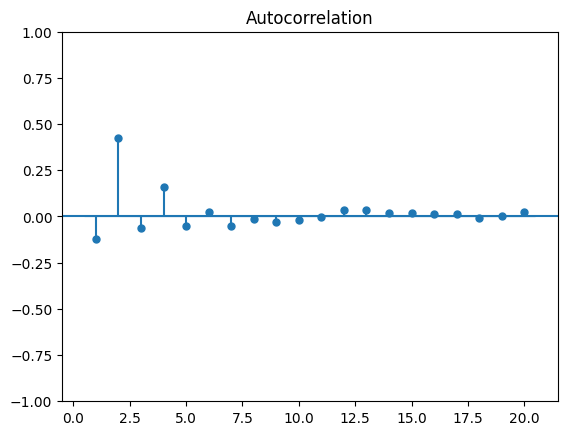

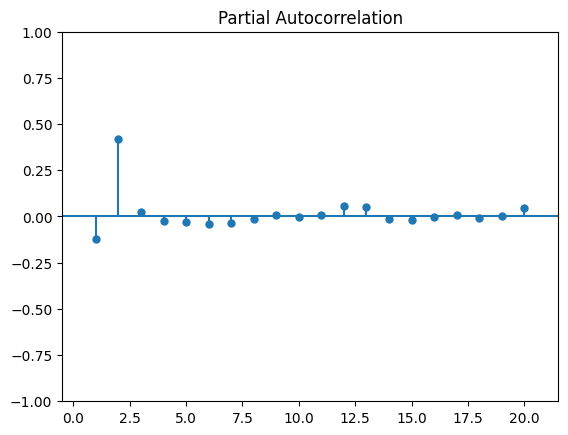

In [14]:
# Модель AR(2)

ar3 = np.array([2, 0.1, -0.8])
ma3 = np.array([1,])
AR_object3 = ArmaProcess(ar3, ma3)
simulated_data_3 = AR_object3.generate_sample(nsample=1000)

plot_acf(simulated_data_3, alpha=0.9, lags=20, zero=False)
plot_pacf(simulated_data_3, alpha=0.9, lags=20, zero=False)
plt.show()

## Процесс авторегрессии произвольного порядка. $AR(p)$

Процесс вида

$$y_t=\phi_1 y_{t-1}+\phi_2 y_{t-2}+...-+\phi_p y_{t-p}+ \epsilon_t  ~~~(1)$$

называется **процессом авторегрессии порядка $p$**

В операторной форме

$\phi (B)y_t = \epsilon_t$

$(1-\phi_1 B-...-\phi_p B^p)y_t = \epsilon_t$

характеристическое уравнение

$1-\phi_1 B-...-\phi_p B^p= 0$

Процесс авторегрессии порядка $p$ стационарен тогда и только тогда корни характеристического уравнения по модулю больше единицы, или корни лежат вне единичной окружности $|z|= 1$

 Умножая (1) на $y_{t-k}$, и ,разделив на $c_0=D[y_t]$, берем математическое ожидание от обоих частей полученного соотношения, получим
  
  
  $\rho_k=\phi_1\rho_{k-1}+...+\phi_p \rho_{k-p}$
  
  Полагая последовательно $k=1,..,p$, получим систему линейных алгебраических уравнений
  
  $\rho_1=\phi_1+...+\phi_p \rho_{p-1}$
  
  $\rho_2=\phi_1\rho_1+...+\phi_p \rho_{p-2}$
  
  $...$
  
  $\rho_p=\phi_1\rho_{p-1}+...+\phi_p$
  
  Эта система уравнений носит название Юла-Уокера. Зная набор чисел $\phi_1,\phi_2,...,\phi_p$ можно из системы вычислить 
 $\rho_1,\rho_2,...,\rho_p$
и наоборот.  

С уравнением Юла Уокера связано появление функции частной автокорреляции
(PACF). Последовательно будем решать их для $k=1,2,...,p$
При $k=1$ оно имет вид
$$\rho_1=\phi_1$$
Решение его обозначим $\phi_{1,1}$.

Для $k=2$
  $$\rho_1=\phi_1+\phi_2\rho_{1}$$
  
  $$\rho_2=\phi_1\rho_1+\phi_2$$
  
Решение его обозначим 

$$\phi_{2,1},\phi_{2,2}$$

И так далее повышаем порядок уравнения и решения для порядка $k$ его обозначаем 

$$\phi_{k,1},\phi_{k,2},..., \phi_{k,k}$$

Функция от $k$, поученная из решений уравнения при старших степенях уравнений
$\phi_{1,1},\phi_{2,2},...,\phi_{p,p},...,\phi_{k,k}$ получила название **частной автокорреляционной функции (PACF)**. 

Для $AR(p)$ она по построению имеет отличные от нуля значения до $\phi_{1,1},\phi_{2,2},...,\phi_{p,p}$
далее при $k>p$ должны следовать нули так как соответствующие $\phi_k$ в модели $AR(p)$ имеются в наличии только до порядка $p$. На практике конечно нули мы не увидим однако, дисперсия  $$D[\phi_{k,k}]\approx\frac{1}{n}$$
попадание значений PACF в полосу $\pm\frac{1}{\sqrt{n}}$ является сигналом к идентификации порядка модели $p$. 


Выражение для дисперсии процесса получим из (1), умножив его на $y_t$,  и , беря математическое ожидание, получим

$D[y_t]= c_0= \frac{\sigma_{\epsilon}^2}{1-\phi_1\rho_1-... -\phi_p\rho_p}$
  


## Смешанные модели ARMA(p,q)

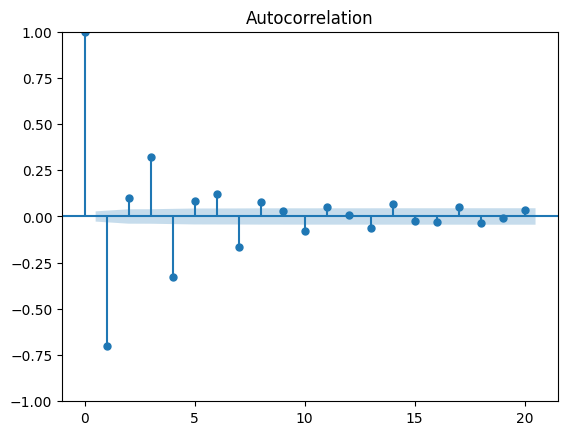

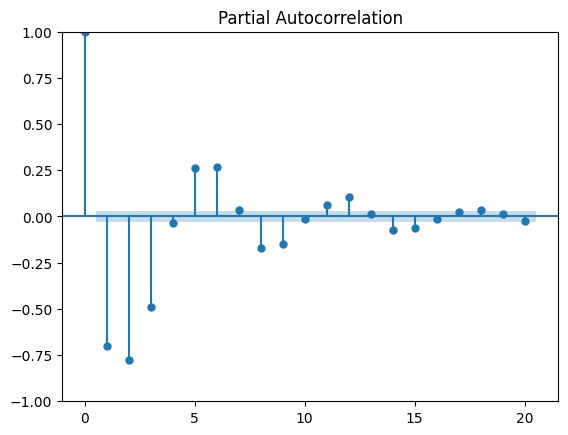

In [26]:
ar = np.array([1, 0.8,  0.55])
ma = np.array([1, -0.9, 0.75])
process = ArmaProcess(ar, ma)
simulated_data = process.generate_sample(nsample=5000)
plot_acf(simulated_data,  lags=20)
plot_pacf(simulated_data, lags=20)
plt.show()

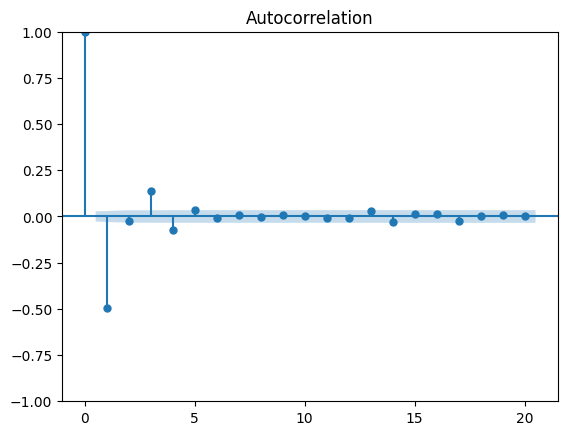

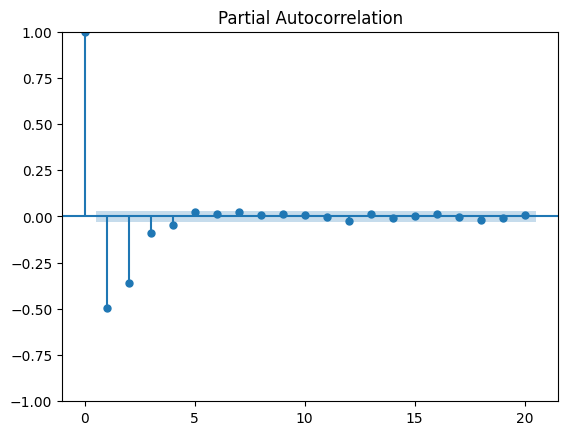

In [24]:
ar = np.array([1, 0.5, ])
ma = np.array([3, -0.6,-0.9,0.5])
process = ArmaProcess(ar, ma)
simulated_data = process.generate_sample(nsample = 5000)
plot_acf(simulated_data,  lags=20)
plot_pacf(simulated_data, lags=20)
plt.show()

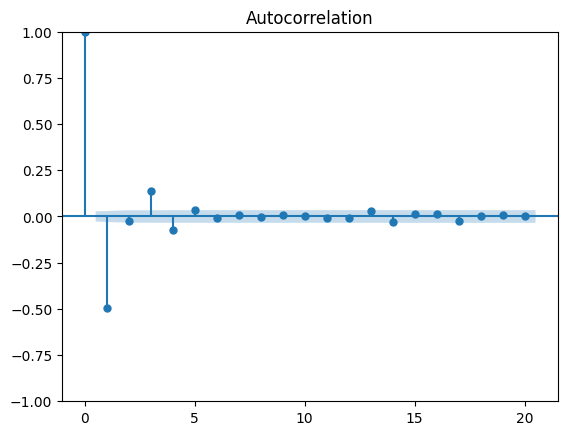

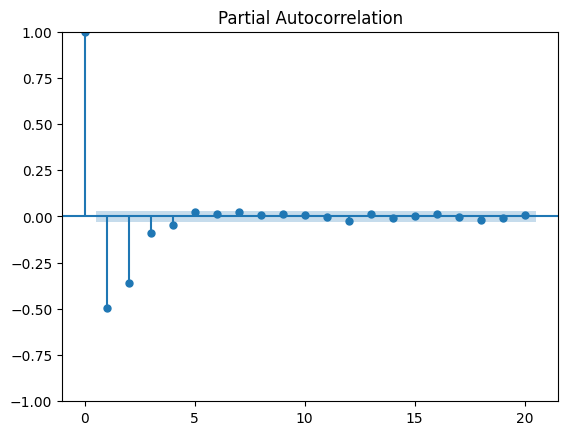

In [25]:
x = pd.Series(simulated_data)#.diff().dropna()
x
plot_acf(x,  lags=20)
plot_pacf(x, lags=20)
plt.show()

In [54]:
ar = np.array([1, -0.8,  0.55])
ma = np.array([1, -0.9, 0.75])
process = ArmaProcess(ar, ma)
simulated_data = process.generate_sample(nsample=365)
arma_mod20 = ARIMA(simulated_data, order=(2, 0, 1), trend='n').fit()
print(arma_mod20.summary())


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  365
Model:                 ARIMA(2, 0, 1)   Log Likelihood                -515.302
Date:                Tue, 08 Sep 2026   AIC                           1038.604
Time:                        09:55:21   BIC                           1054.204
Sample:                             0   HQIC                          1044.804
                                - 365                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4948      0.187      2.652      0.008       0.129       0.860
ar.L2          0.1998      0.058      3.471      0.001       0.087       0.313
ma.L1         -0.5597      0.186     -3.003      0.0

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [55]:
arma_mod20 = ARIMA(simulated_data, order=(1, 0, 1), trend='n').fit()
print(arma_mod20.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  365
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -520.946
Date:                Tue, 08 Sep 2026   AIC                           1047.893
Time:                        09:55:27   BIC                           1059.593
Sample:                             0   HQIC                          1052.542
                                - 365                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9933      0.012     79.714      0.000       0.969       1.018
ma.L1         -0.9769      0.023    -41.814      0.000      -1.023      -0.931
sigma2         1.0157      0.077     13.152      0.0

In [56]:
stepwise_model = pm.auto_arima(simulated_data, start_p=1, start_q=1,
                           start_P=0, seasonal=False,
                           trace=True,
                           error_action='ignore',  
                           suppress_warnings=True, 
                           stepwise=True, information_criterion='bic') 

Performing stepwise search to minimize bic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : BIC=inf, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : BIC=1324.638, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : BIC=1177.707, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : BIC=inf, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : BIC=1318.741, Time=0.00 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : BIC=1112.498, Time=0.01 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : BIC=1102.384, Time=0.01 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : BIC=1099.375, Time=0.02 sec
 ARIMA(5,1,0)(0,0,0)[0] intercept   : BIC=1105.160, Time=0.02 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : BIC=inf, Time=0.12 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : BIC=inf, Time=0.09 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : BIC=inf, Time=0.13 sec
 ARIMA(4,1,0)(0,0,0)[0]             : BIC=1093.480, Time=0.01 sec
 ARIMA(3,1,0)(0,0,0)[0]             : BIC=1096.487, Time=0.01 sec
 ARIMA(5,1,0)(0,0,0)[0]             : BIC=1099.265, Time=0

In [57]:
model = pm.auto_arima(simulated_data, start_p=1, start_q=1, start_P=1, start_Q=1,
                     max_p=5, max_q=5, max_P=5, max_Q=5, seasonal=True,
                     stepwise=True, suppress_warnings=True, D=10, max_D=10,
                     error_action='ignore')

In [58]:
model = pm.auto_arima(simulated_data)

In [59]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  365
Model:               SARIMAX(3, 1, 1)   Log Likelihood                -512.962
Date:                Tue, 08 Sep 2026   AIC                           1035.924
Time:                        09:58:51   BIC                           1055.410
Sample:                             0   HQIC                          1043.669
                                - 365                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0889      0.052     -1.697      0.090      -0.192       0.014
ar.L2          0.1176      0.058      2.035      0.042       0.004       0.231
ar.L3          0.1729      0.053      3.241      0.001       0.068       0.277
ma.L1         -0.9851      0.011    -86.323      0.000      -1.007      -0.963
sigma2         0.9722      0.074     13.137      0.000       0.827       1.117
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 2.61
Prob(Q):                              0.93   Prob(JB):                         0.27
Heteroskedasticity (H):               1.10   Skew:                            -0.20
Prob(H) (two-sided):                  0.61   Kurtosis:                         2.88
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

**Ljung-Box (L1) (Q)** - статистика теста Льюинга-Бокса (нулевая гипотеза - остатки нормальные)

**Prob(Q)** - p-value соответствующее статистики теста Льюинга-Бокса

**Heteroskedasticity** - нулевая гипотеза о гомоскедастичности (одинаковой дисперсии)

**Jarque-Bera (JB)** - тест на нормальность остатков

**Prob(JB)** - p-value данного теста

**z-statistics** - статистика для проверки нулевой гипотезы о равенстве соответствующего коэффициента нулю.

**P>|z|** - p-value для проверки описанной выше гипотезы

**[0.025 0.975]** - доверительные интервалы для значений параметров

**AIC:** - информационный критерий Акаике, численное значение само по себе ничего не дает, используется для сравнения моделей - чем меньше, тем лучше. Формула $AIC = 2*k -2*log~likehood$

**BIC** - Байесовский информационный критерий ($BIC = ln(n)*k -2*log~likehood$), аналогично чем меньше - тем лучше

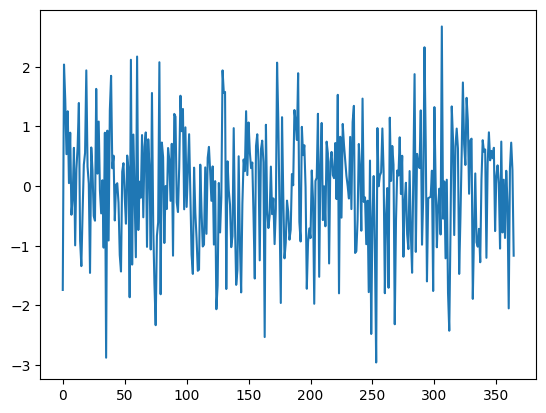

In [60]:
plt.plot(model.resid())
plt.show()

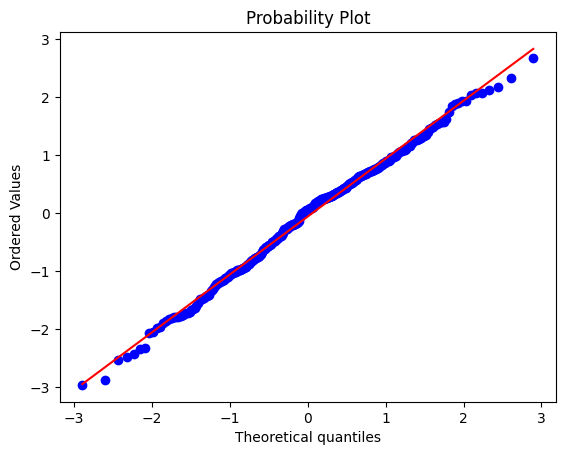

In [61]:
stats.probplot(model.resid(), dist="norm", plot=pylab)
pylab.show()

In [65]:
ar = np.array([1, -0.8,  0.55])
ma = np.array([1, -0.9, 0.75])
process = ArmaProcess(ar, ma)
simulated_data = process.generate_sample(nsample=3650)
sm.tsa.stattools.arma_order_select_ic(simulated_data, max_ar=10, max_ma=5, ic='aic', trend='n', model_kw=None, fit_kw=None)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to conver

{'aic':                0             1             2             3             4  \
 0   10363.358505  10347.791622  10287.691703  10200.727983  10186.816129   
 1   10343.641697  10335.528176  10224.481153  10192.226207  10188.113419   
 2   10303.627631  10257.548862  10165.340514  10167.235380  10168.567219   
 3   10228.938918  10225.512579  10167.228288  10169.338152  10171.210074   
 4   10221.080996  10221.471086  10168.537030  10171.196522  10173.332755   
 5   10217.293369  10202.429540  10169.964071  10171.749156  10173.548789   
 6   10195.929825  10192.070901  10171.358531  10173.964062  10175.570746   
 7   10186.908026  10188.597345  10173.000524  10175.023858  10175.898856   
 8   10188.109877  10186.772173  10175.000089  10176.918838  10178.893930   
 9   10182.291307  10183.362829  10175.936932  10178.437975  10180.168548   
 10  10181.594096  10181.401566  10177.694352  10179.631824  10182.204792   
 
                5  
 0   10186.856172  
 1   10179.234053  
 2   10